# Stage 1: EDA & Data Understanding — KolektorSDD

**목표:** 데이터셋 구조 파악, 클래스 분포 분석, Part-level stratified split 생성, 픽셀 통계 계산.

| 항목 | 내용 |
|---|---|
| 총 이미지 | 399장 |
| 결함(defect) | 52장 |
| 정상(normal) | 347장 |
| 불균형 비율 | 6.67:1 |
| Part 수 | 50개 (kos01~kos50) |

## Cell 1 — Setup

In [ ]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import yaml
from datetime import datetime

# 재현성
np.random.seed(42)

# 경로 설정
ROOT = Path('..').resolve()
RAW_DIR = ROOT / 'data' / 'raw' / 'KolektorSDD-boxes'
PROCESSED_DIR = ROOT / 'data' / 'processed'
FIGURES_DIR = ROOT / 'experiments' / 'eda' / 'figures'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'ROOT       : {ROOT}')
print(f'RAW_DIR    : {RAW_DIR}')
print(f'PROCESSED  : {PROCESSED_DIR}')
print(f'FIGURES    : {FIGURES_DIR}')

assert RAW_DIR.exists(), f'데이터 디렉토리가 없습니다: {RAW_DIR}\n'\
    'data/raw/KolektorSDD-boxes/ 아래 kos01~kos50 폴더를 배치하세요.'

ROOT       : /home/jinxin4u/dl/bin/projects/kolektorsdd-classification
RAW_DIR    : /home/jinxin4u/dl/bin/projects/kolektorsdd-classification/data/raw/KolektorSDD-boxes
PROCESSED  : /home/jinxin4u/dl/bin/projects/kolektorsdd-classification/data/processed
FIGURES    : /home/jinxin4u/dl/bin/projects/kolektorsdd-classification/reports/figures


## Cell 2 — 파일 수 검증

In [2]:
part_dirs = sorted([d for d in RAW_DIR.iterdir() if d.is_dir() and d.name.startswith('kos')])
print(f'발견된 Part 수: {len(part_dirs)}')

summary_rows = []
for part_dir in part_dirs:
    jpg_files = sorted(part_dir.glob('*.jpg'))
    bmp_files = sorted(part_dir.glob('*_label.bmp'))
    summary_rows.append({
        'part': part_dir.name,
        'n_images': len(jpg_files),
        'n_masks': len(bmp_files),
    })

summary_df = pd.DataFrame(summary_rows)
total_images = summary_df['n_images'].sum()
total_masks  = summary_df['n_masks'].sum()

print(f'\n총 이미지 수 : {total_images}')
print(f'총 마스크 수 : {total_masks}')
print(f'\nPart별 파일 수 (상위 10개):')
print(summary_df.head(10).to_string(index=False))

# 경고: 이미지 수 != 마스크 수인 part
mismatch = summary_df[summary_df['n_images'] != summary_df['n_masks']]
if len(mismatch) > 0:
    print(f'\n[WARNING] 이미지/마스크 수 불일치 Part:')
    print(mismatch.to_string(index=False))
else:
    print(f'\n모든 Part에서 이미지-마스크 1:1 대응 확인됨.')

발견된 Part 수: 50

총 이미지 수 : 399
총 마스크 수 : 399

Part별 파일 수 (상위 10개):
 part  n_images  n_masks
kos01         8        8
kos02         8        8
kos03         8        8
kos04         8        8
kos05         8        8
kos06         8        8
kos07         8        8
kos08         8        8
kos09         8        8
kos10         8        8

모든 Part에서 이미지-마스크 1:1 대응 확인됨.


## Cell 3 — 레이블 생성 (mask 기반)

> **규칙:** `label = 1 if np.any(np.array(mask) > 0) else 0`  
> bmp 이미지를 numpy 배열로 변환하여, 픽셀 값이 0보다 큰 게 하나라도 있다면, 결함부위에 흰박스를 쳐놓은게 있다는 의미.

In [3]:
records = []
for part_dir in part_dirs:
    jpg_files = sorted(part_dir.glob('*.jpg'))
    for jpg_path in jpg_files:
        # 대응 mask 파일: stem + '_label.bmp'
        mask_path = part_dir / (jpg_path.stem + '_label.bmp')
        if not mask_path.exists():
            print(f'[WARNING] 마스크 없음: {mask_path}')
            continue
        mask = np.array(Image.open(mask_path))
        label = 1 if np.any(mask > 0) else 0
        # image_path: 프로젝트 루트 기준 상대경로
        rel_path = jpg_path.relative_to(ROOT).as_posix()
        records.append({
            'part': part_dir.name,
            'image_path': rel_path,
            'label': label,
        })

all_df = pd.DataFrame(records)
print(f'전체 레코드 수: {len(all_df)}')
print(f'\n클래스 분포:')
vc = all_df['label'].value_counts().sort_index()
print(f'  정상 (0): {vc.get(0, 0)}')
print(f'  결함 (1): {vc.get(1, 0)}')
print(f'  불균형 비율 (normal:defect) = {vc.get(0,0)/vc.get(1,1):.2f}:1')
print(f'\nPart별 defect 비율:')
part_stats = all_df.groupby('part')['label'].agg(['sum','count'])
part_stats.columns = ['n_defect', 'n_total']
part_stats['defect_ratio'] = part_stats['n_defect'] / part_stats['n_total']
print(part_stats.to_string())

전체 레코드 수: 399

클래스 분포:
  정상 (0): 347
  결함 (1): 52
  불균형 비율 (normal:defect) = 6.67:1

Part별 defect 비율:
       n_defect  n_total  defect_ratio
part                                  
kos01         1        8      0.125000
kos02         1        8      0.125000
kos03         1        8      0.125000
kos04         1        8      0.125000
kos05         1        8      0.125000
kos06         1        8      0.125000
kos07         1        8      0.125000
kos08         1        8      0.125000
kos09         1        8      0.125000
kos10         1        8      0.125000
kos11         1        8      0.125000
kos12         1        8      0.125000
kos13         1        8      0.125000
kos14         1        8      0.125000
kos15         1        8      0.125000
kos16         1        8      0.125000
kos17         1        8      0.125000
kos18         1        8      0.125000
kos19         1        8      0.125000
kos20         1        8      0.125000
kos21         1        7      0.142857
k

## Cell 4 — Part-level Stratified Split

**분할 원칙:**
- 반드시 Part 단위로 분할 (이미지 단위 분할 시 data leakage 발생)
- 50 parts → train 35 / val 7 / test 8
- 각 split에서 결함 비율이 균등하도록 stratify
- seed=42

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit

# Part 단위 집계: 각 part가 defect를 포함하는지 여부
part_label_df = (
    all_df.groupby('part')['label']
    .apply(lambda x: 1 if x.sum() > 0 else 0)
    .reset_index()
)
part_label_df.columns = ['part', 'has_defect']

parts_array = part_label_df['part'].values
has_defect_array = part_label_df['has_defect'].values

print(f'전체 Part 수: {len(parts_array)}')
print(f'  결함 포함 Part: {has_defect_array.sum()}')
print(f'  결함 없는  Part: {(1 - has_defect_array).sum()}')

# Step 1: train+val vs test  (test = ~16%, ~8 parts)
sss_test = StratifiedShuffleSplit(n_splits=1, test_size=8, random_state=42)
trainval_idx, test_idx = next(sss_test.split(parts_array, has_defect_array))

trainval_parts  = parts_array[trainval_idx]
trainval_labels = has_defect_array[trainval_idx]
test_parts      = parts_array[test_idx]

# Step 2: train vs val  (val = 7 parts from remaining 42)
sss_val = StratifiedShuffleSplit(n_splits=1, test_size=7, random_state=42)
train_idx, val_idx = next(sss_val.split(trainval_parts, trainval_labels))

train_parts = trainval_parts[train_idx]
val_parts   = trainval_parts[val_idx]

# 검증: 3 split이 완전히 disjoint한지 확인
assert set(train_parts).isdisjoint(set(val_parts)),   'train/val 중복 Part 존재!'
assert set(train_parts).isdisjoint(set(test_parts)),  'train/test 중복 Part 존재!'
assert set(val_parts).isdisjoint(set(test_parts)),    'val/test 중복 Part 존재!'
assert len(train_parts) + len(val_parts) + len(test_parts) == len(parts_array), 'Part 수 불일치!'

print(f'\nSplit 결과 (Part 단위):')
print(f'  train : {len(train_parts)} parts  {sorted(train_parts)}')
print(f'  val   : {len(val_parts)} parts  {sorted(val_parts)}')
print(f'  test  : {len(test_parts)} parts  {sorted(test_parts)}')

# DataFrame 생성
train_df = all_df[all_df['part'].isin(train_parts)].reset_index(drop=True)
val_df   = all_df[all_df['part'].isin(val_parts)].reset_index(drop=True)
test_df  = all_df[all_df['part'].isin(test_parts)].reset_index(drop=True)

print(f'\nSplit 결과 (이미지 단위):')
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    n_def = df['label'].sum()
    n_nor = (df['label'] == 0).sum()
    ratio = n_def / len(df) * 100
    print(f'  {name:5s}: {len(df):3d}장  defect={n_def:2d}  normal={n_nor:3d}  defect율={ratio:.1f}%')

total = len(train_df) + len(val_df) + len(test_df)
print(f'\n합계 검증: {total} == {len(all_df)} => {total == len(all_df)}')

전체 Part 수: 50
  결함 포함 Part: 50
  결함 없는  Part: 0

Split 결과 (Part 단위):
  train : 35 parts  ['kos01', 'kos02', 'kos03', 'kos04', 'kos06', 'kos09', 'kos10', 'kos13', 'kos14', 'kos17', 'kos18', 'kos20', 'kos22', 'kos23', 'kos24', 'kos25', 'kos26', 'kos27', 'kos28', 'kos30', 'kos31', 'kos33', 'kos34', 'kos35', 'kos36', 'kos37', 'kos38', 'kos40', 'kos41', 'kos42', 'kos44', 'kos45', 'kos46', 'kos47', 'kos49']
  val   : 7 parts  ['kos05', 'kos07', 'kos11', 'kos12', 'kos16', 'kos32', 'kos48']
  test  : 8 parts  ['kos08', 'kos15', 'kos19', 'kos21', 'kos29', 'kos39', 'kos43', 'kos50']

Split 결과 (이미지 단위):
  train: 280장  defect=36  normal=244  defect율=12.9%
  val  :  56장  defect= 7  normal= 49  defect율=12.5%
  test :  63장  defect= 9  normal= 54  defect율=14.3%

합계 검증: 399 == 399 => True


## Cell 5 — CSV 저장

In [5]:
# columns: part, image_path (루트 기준 상대경로), label
train_df[['part', 'image_path', 'label']].to_csv(PROCESSED_DIR / 'train.csv', index=False)
val_df[['part', 'image_path', 'label']].to_csv(PROCESSED_DIR / 'val.csv', index=False)
test_df[['part', 'image_path', 'label']].to_csv(PROCESSED_DIR / 'test.csv', index=False)

print('CSV 저장 완료:')
print(f'  {PROCESSED_DIR / "train.csv"}')
print(f'  {PROCESSED_DIR / "val.csv"}')
print(f'  {PROCESSED_DIR / "test.csv"}')

print('\n각 split 레이블 분포:')
for name, path in [('train', 'train.csv'), ('val', 'val.csv'), ('test', 'test.csv')]:
    df = pd.read_csv(PROCESSED_DIR / path)
    vc = df['label'].value_counts().sort_index()
    print(f'  {name:5s}: total={len(df)}  normal={vc.get(0,0)}  defect={vc.get(1,0)}')

# 합계 검증
totals = sum(len(pd.read_csv(PROCESSED_DIR / p)) for p in ['train.csv','val.csv','test.csv'])
print(f'\n합계 검증: {totals} == 399 => {totals == 399}')

CSV 저장 완료:
  /home/jinxin4u/dl/bin/projects/kolektorsdd-classification/data/processed/train.csv
  /home/jinxin4u/dl/bin/projects/kolektorsdd-classification/data/processed/val.csv
  /home/jinxin4u/dl/bin/projects/kolektorsdd-classification/data/processed/test.csv

각 split 레이블 분포:
  train: total=280  normal=244  defect=36
  val  : total=56  normal=49  defect=7
  test : total=63  normal=54  defect=9

합계 검증: 399 == 399 => True


## Cell 6 — 픽셀 통계 계산 (train split만)

> **Data leakage 방지:** val/test 이미지는 통계 계산에서 제외.

In [6]:
print('Train split 픽셀 통계 계산 중...')
print(f'(대상 이미지: {len(train_df)}장)')

# Welford's online algorithm 방식으로 메모리 효율적 계산
pixel_sum    = np.zeros(3, dtype=np.float64)
pixel_sq_sum = np.zeros(3, dtype=np.float64)
pixel_count  = 0

widths, heights = [], []

for _, row in train_df.iterrows():
    img_path = ROOT / row['image_path']
    img = np.array(Image.open(img_path).convert('RGB'), dtype=np.float64)
    h, w, c = img.shape
    widths.append(w)
    heights.append(h)
    pixel_sum    += img.sum(axis=(0, 1))
    pixel_sq_sum += (img ** 2).sum(axis=(0, 1))
    pixel_count  += h * w

mean_255 = pixel_sum / pixel_count
std_255  = np.sqrt(pixel_sq_sum / pixel_count - mean_255 ** 2)

# [0,1] 정규화
mean_norm = (mean_255 / 255.0).tolist()
std_norm  = (std_255  / 255.0).tolist()

min_size = (min(widths), min(heights))
max_size = (max(widths), max(heights))

print(f'\nPer-channel Mean (0~255): R={mean_255[0]:.2f}  G={mean_255[1]:.2f}  B={mean_255[2]:.2f}')
print(f'Per-channel Std  (0~255): R={std_255[0]:.2f}   G={std_255[1]:.2f}   B={std_255[2]:.2f}')
print(f'\nNormalized Mean [0,1]: {[round(v,4) for v in mean_norm]}')
print(f'Normalized Std  [0,1]: {[round(v,4) for v in std_norm]}')
print(f'\n이미지 크기 범위:')
print(f'  min (W x H): {min_size[0]} x {min_size[1]}')
print(f'  max (W x H): {max_size[0]} x {max_size[1]}')

Train split 픽셀 통계 계산 중...
(대상 이미지: 280장)

Per-channel Mean (0~255): R=186.59  G=186.59  B=186.59
Per-channel Std  (0~255): R=23.32   G=23.32   B=23.32

Normalized Mean [0,1]: [0.7317, 0.7317, 0.7317]
Normalized Std  [0,1]: [0.0915, 0.0915, 0.0915]

이미지 크기 범위:
  min (W x H): 500 x 1235
  max (W x H): 500 x 1285


## Cell 7 — 시각화

/tmp/ipykernel_13575/1219545431.py:31: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13575/1219545431.py:31: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13575/1219545431.py:32: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_13575/1219545431.py:32: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
/home/jinxin4u/dl/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jinxin4u/dl/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: Us

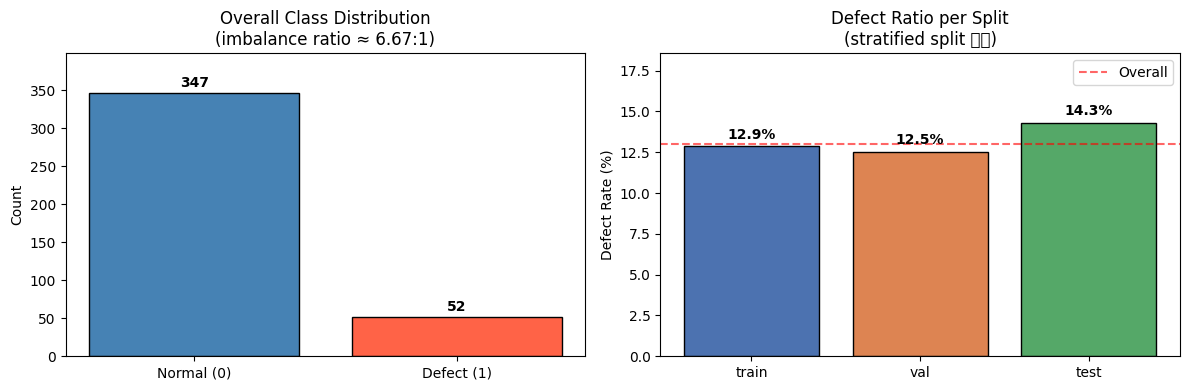

저장: /home/jinxin4u/dl/bin/projects/kolektorsdd-classification/reports/figures/class_distribution.png


In [7]:
# ── 7-1. 클래스 분포 bar chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 전체 클래스 분포
ax = axes[0]
counts = all_df['label'].value_counts().sort_index()
bars = ax.bar(['Normal (0)', 'Defect (1)'], [counts.get(0, 0), counts.get(1, 0)],
              color=['steelblue', 'tomato'], edgecolor='black')
for bar, v in zip(bars, [counts.get(0, 0), counts.get(1, 0)]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            str(v), ha='center', va='bottom', fontweight='bold')
ax.set_title('Overall Class Distribution\n(imbalance ratio ≈ 6.67:1)', fontsize=12)
ax.set_ylabel('Count')
ax.set_ylim(0, max(counts) * 1.15)

# Split별 defect 비율
ax = axes[1]
split_names = ['train', 'val', 'test']
split_dfs   = [train_df, val_df, test_df]
defect_ratios = [df['label'].mean() * 100 for df in split_dfs]
bars = ax.bar(split_names, defect_ratios, color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
for bar, v in zip(bars, defect_ratios):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.axhline(all_df['label'].mean() * 100, color='red', linestyle='--', alpha=0.6, label='Overall')
ax.set_title('Defect Ratio per Split\n(stratified split 검증)', fontsize=12)
ax.set_ylabel('Defect Rate (%)')
ax.set_ylim(0, max(defect_ratios) * 1.3)
ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {FIGURES_DIR / "class_distribution.png"}')

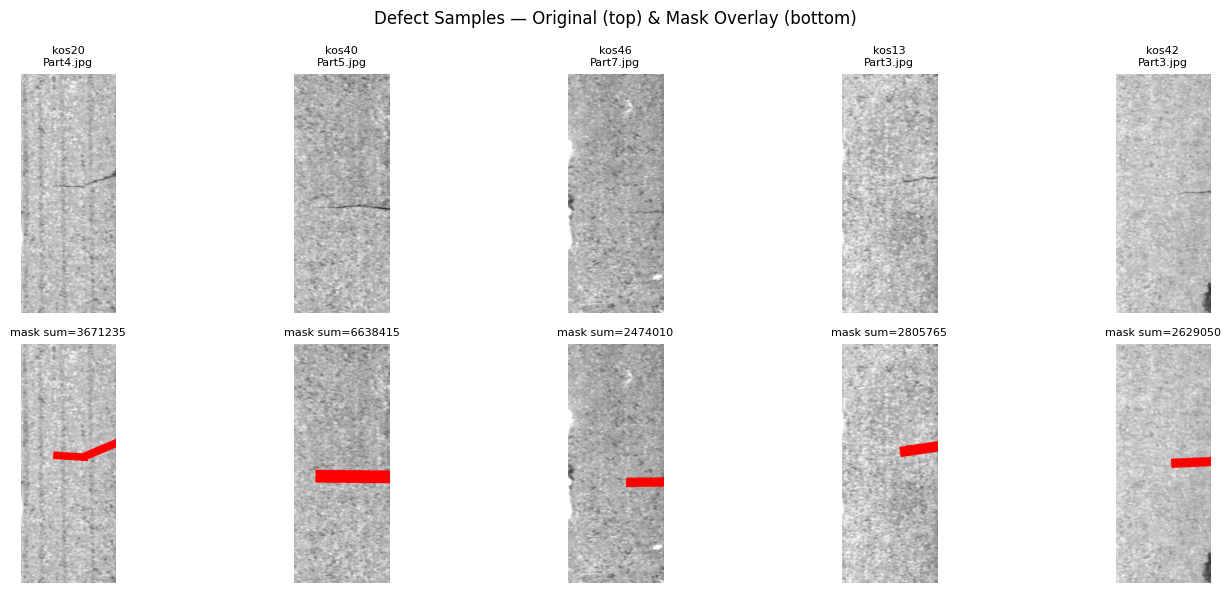

저장: /home/jinxin4u/dl/bin/projects/kolektorsdd-classification/reports/figures/defect_samples.png


In [8]:
# ── 7-2. 결함 샘플 (defect 5장) + mask overlay ─────────────────────────────
defect_rows = all_df[all_df['label'] == 1].sample(n=min(5, (all_df['label']==1).sum()),
                                                    random_state=42)
fig, axes = plt.subplots(2, len(defect_rows), figsize=(3 * len(defect_rows), 6))
fig.suptitle('Defect Samples — Original (top) & Mask Overlay (bottom)', fontsize=12)

for col, (_, row) in enumerate(defect_rows.iterrows()):
    img_path  = ROOT / row['image_path']
    mask_path = ROOT / row['image_path'].replace('.jpg', '_label.bmp')
    img  = np.array(Image.open(img_path).convert('RGB'))
    mask = np.array(Image.open(mask_path))

    # Original
    axes[0][col].imshow(img, cmap='gray' if img.shape[2] == 1 else None)
    axes[0][col].set_title(f"{row['part']}\n{Path(row['image_path']).name}", fontsize=8)
    axes[0][col].axis('off')

    # Mask overlay (결함 영역 빨간색)
    overlay = img.copy()
    overlay[mask > 0] = [255, 0, 0]
    axes[1][col].imshow(overlay)
    axes[1][col].set_title(f'mask sum={mask.sum()}', fontsize=8)
    axes[1][col].axis('off')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'defect_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {FIGURES_DIR / "defect_samples.png"}')

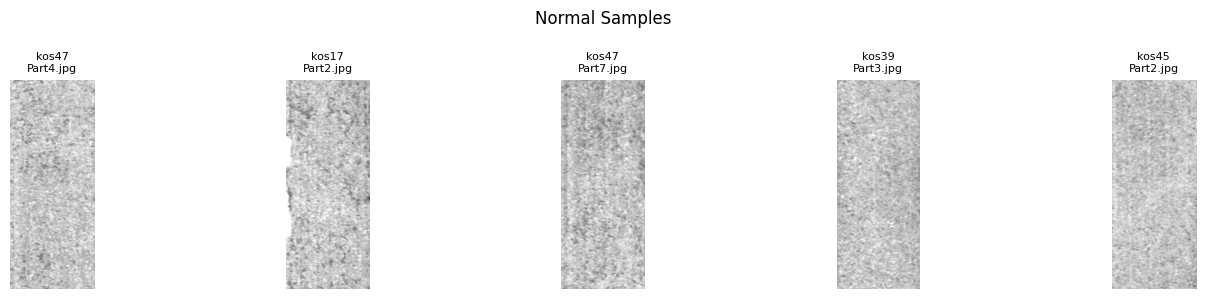

저장: /home/jinxin4u/dl/bin/projects/kolektorsdd-classification/reports/figures/normal_samples.png


In [9]:
# ── 7-3. 정상 샘플 (normal 5장) ─────────────────────────────────────────────
normal_rows = all_df[all_df['label'] == 0].sample(n=5, random_state=42)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Normal Samples', fontsize=12)

for col, (_, row) in enumerate(normal_rows.iterrows()):
    img = np.array(Image.open(ROOT / row['image_path']).convert('RGB'))
    axes[col].imshow(img)
    axes[col].set_title(f"{row['part']}\n{Path(row['image_path']).name}", fontsize=8)
    axes[col].axis('off')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'normal_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {FIGURES_DIR / "normal_samples.png"}')

In [10]:
# ── 7-4. Train split 픽셀 강도 히스토그램 (RGB 채널별) ──────────────────────
# 메모리 효율: 이미지별로 np.histogram 누적 (pixel 값 전체를 메모리에 쌓지 않음)
print('픽셀 히스토그램 계산 중 (train 샘플 50장)...')
sample_rows = train_df.sample(n=min(50, len(train_df)), random_state=42)

bins = np.arange(0, 257, 1)   # 256개 구간
r_counts = np.zeros(256, dtype=np.int64)
g_counts = np.zeros(256, dtype=np.int64)
b_counts = np.zeros(256, dtype=np.int64)

for _, row in sample_rows.iterrows():
    img = np.array(Image.open(ROOT / row['image_path']).convert('RGB'), dtype=np.uint8)
    r_counts += np.bincount(img[:, :, 0].ravel(), minlength=256)
    g_counts += np.bincount(img[:, :, 1].ravel(), minlength=256)
    b_counts += np.bincount(img[:, :, 2].ravel(), minlength=256)
    del img   # 즉시 해제

total = r_counts.sum()
x = np.arange(256)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(x, r_counts / total, alpha=0.4, color='red',   label='R', step='mid')
ax.fill_between(x, g_counts / total, alpha=0.4, color='green', label='G', step='mid')
ax.fill_between(x, b_counts / total, alpha=0.4, color='blue',  label='B', step='mid')
ax.set_title('Pixel Intensity Histogram — Train Split (50 samples)', fontsize=12)
ax.set_xlabel('Pixel Value (0–255)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'pixel_histogram.png', dpi=150, bbox_inches='tight')
plt.close(fig)   # GUI 없는 환경에서 메모리 해제
print(f'저장: {FIGURES_DIR / "pixel_histogram.png"}')


픽셀 히스토그램 계산 중 (train 샘플 50장)...
저장: /home/jinxin4u/dl/bin/projects/kolektorsdd-classification/reports/figures/pixel_histogram.png


## 완료 요약

| 산출물 | 경로 |
|---|---|
| 노트북 | `notebooks/01_eda.ipynb` |
| Train CSV | `data/processed/train.csv` |
| Val CSV | `data/processed/val.csv` |
| Test CSV | `data/processed/test.csv` |
| 클래스 분포 차트 | `reports/figures/class_distribution.png` |
| 결함 샘플 이미지 | `reports/figures/defect_samples.png` |
| 정상 샘플 이미지 | `reports/figures/normal_samples.png` |
| 픽셀 히스토그램 | `reports/figures/pixel_histogram.png` |
| 상태 파일 | `state.yaml` (Stage 1 complete) |